# Hamiltonian simulation: build, evolve, measure

- **Build an evolution circuit** from a Hamiltonian written as Pauli terms.
- **Measure observables directly**, with expectation values and uncertainties calculated by the library.
- **Swap circuit components**: replace the underlying rotation implementation while keeping the evolution and measurement interfaces.

This demo follows one two-qubit system from preparation to measured dynamics. The same components can be reused for other Hamiltonians and input states.

| What you want to do | Library component |
| :-- | :-- |
| Build a Trotter step | `trotter_first_order` |
| Evolve for several steps | `ham_sim_trotter` |
| Measure a Pauli observable | `make_direct_measure_pauli_simple` |
| Calculate a mean and uncertainty | `estimate_pauli_observable_expectation_from_bitstrings` |
| Replace the rotation implementation | The step factory's `rz_method` argument |

- Each section introduces one part of the workflow, with runnable code and saved results.
- Run from a source checkout with development dependencies installed. The repository default is little endian.


In [1]:
import numpy as np
import pandas as pd
import zixy.qubit.pauli as zqp
from scipy.linalg import expm
from matplotlib import pyplot as plt
from guppylang import guppy
from guppylang.std.builtins import array
from guppylang.std.quantum import qubit, h
from guppyalgos.utils import qarray, transversal
from guppyalgos.algorithms.time_evolution.trotter import ham_sim_trotter, trotter_first_order
from guppyalgos.primitives.measurement import (
    make_direct_measure_pauli_simple,
    estimate_pauli_observable_expectation_from_bitstrings,
)

## 1. Build an evolution circuit

### Choose a Hamiltonian

- Describe the system as a weighted sum of Pauli strings, $H=\sum_j a_jP_j$.
- This example uses two qubits and four terms:

$$
H=-0.5Z_0X_1-0.1X_0Z_1-0.2Y_0Y_1-0.3X_0X_1.
$$

- Change the coefficients and Pauli strings to describe a different system.

In [2]:
hamiltonian = zqp.RealTermSum.from_str(
    "(-0.5, Z0 X1), (-0.1, X0 Z1), (-0.2, Y0 Y1), (-0.3, X0 X1)", 2,
)
n_qubits = 2
time_step = 0.2
n_shots = 1024

### Compose the simulation

- `trotter_first_order` builds one step from the Hamiltonian.
- `ham_sim_trotter` repeats it. Five steps of size $0.2$ give total time $t=1$.

$$
U_r(t)=\left[\prod_j e^{-i\pi\Delta t\,a_jP_j/2}\right]^r,
\qquad t=r\Delta t.
$$

In [3]:
trotter_step = trotter_first_order(hamiltonian, n_qubits)
simulation = ham_sim_trotter(trotter_step, n_steps=5, time_step=time_step, n_state_qubits=n_qubits)

### Choose the input state

- `qreg` holds the two system qubits.
- `transversal(h, qreg)` prepares $|+\rangle^{\otimes2}$; `simulation(qreg)` evolves it.
- Replace the preparation gates to study a different initial state.

In [4]:
@guppy
def prepare(qreg: array[qubit, 2]) -> None:
    transversal(h, qreg)
    simulation(qreg)

## 2. Measure an observable

### Choose the measurement basis

- `make_direct_measure_pauli_simple` builds the basis changes and measurements for a Pauli string.
- Use the same interface for $X$, $Y$, $Z$, or products such as $Z_0X_1$.
- The small runner below prepares a fresh state for each shot and collects the library's measurement output.

In [5]:
def sample_direct(preparation, pauli, seed=7, extra_qubits=0, shots=n_shots):
    measurement = make_direct_measure_pauli_simple(pauli, n_qubits)

    @guppy
    def experiment() -> None:
        qreg = qarray(n_qubits)
        preparation(qreg)
        measurement(qreg)

    result = experiment.emulator(n_qubits + extra_qubits).with_seed(seed).with_shots(shots).run()
    return [shot["bitstring"][0] for shot in result.collated_shots()]

### Turn shots into an expectation value

- Ask for $\langle Z_0\rangle$ and collect 1,024 shots.
- The built-in estimator handles parity, averaging, and standard error:

$$
\widehat{\langle P\rangle}=\frac{N_+-N_-}{N},
\qquad \mathrm{SE}=\sqrt{\frac{1-\widehat{\langle P\rangle}^2}{N}}.
$$

- A Pauli expectation lies in $[-1,1]$. For $Z_0$, the corresponding probability is $\Pr(q_0=1)=(1-\langle Z_0\rangle)/2$.

In [6]:
observable = zqp.RealTermSum.from_str("Z0", n_qubits)
pauli = zqp.String.from_str("Z0", n_qubits)
samples = sample_direct(prepare, pauli)
estimate = estimate_pauli_observable_expectation_from_bitstrings(observable, {str(pauli): samples})
print(pd.DataFrame([{
    "Observable": "Z0", "Expectation": estimate.expectation,
    "Standard error": estimate.standard_error, "Shots": n_shots,
}]).to_string(index=False, float_format=lambda value: f"{value:.4f}"))


Observable  Expectation  Standard error  Shots
        Z0       0.3633          0.0291   1024


## 3. See the dynamics

- Increase the number of steps to follow the state over time.
- Measure $\langle Z_0\rangle$ and $\langle Z_1\rangle$ using the same measurement runner.
- Here $\Delta t=0.2$ stays fixed, so more steps mean a longer evolution. To improve the Trotter approximation at a **fixed** time, increase the step count while reducing $\Delta t=t/r$.

### Set up a reference

- Exact evolution uses $e^{-i\pi tH/2}$.
- The Trotter reference multiplies the same Pauli rotations as the circuit, with later gates on the left.
- Keeping both references lets us distinguish approximation error from measurement noise.

In [7]:
initial_state = np.ones(2**n_qubits) / np.sqrt(2**n_qubits)
h_matrix = np.asarray(hamiltonian.to_sparse_matrix(True).todense())
step_matrix = np.eye(2**n_qubits, dtype=complex)
for term in hamiltonian.to_terms():
    matrix = float(term.coeff) * np.asarray(term.string.to_sparse_matrix(True).todense())
    step_matrix = expm(-0.5j * np.pi * time_step * matrix) @ step_matrix


def reference_mean(state, operator):
    matrix = np.asarray(operator.to_sparse_matrix(True).todense())
    return float(np.vdot(state, matrix @ state).real)

### Reuse the circuit and measurement builders

- Build an evolution for each time point.
- Pass each observable to the same `sample_direct` runner.
- Check the measured values against the Trotter reference, allowing for finite-shot noise.

In [8]:
step_counts = [0, 2, 4, 6, 8, 10]
rows = []
for steps in step_counts:
    evolve = ham_sim_trotter(trotter_step, steps, time_step, n_qubits)

    @guppy
    def prepare_at_time(qreg: array[qubit, 2]) -> None:
        transversal(h, qreg)
        evolve(qreg)

    time = steps * time_step
    exact_state = expm(-0.5j * np.pi * time * h_matrix) @ initial_state
    trotter_state = np.linalg.matrix_power(step_matrix, steps) @ initial_state
    for index in range(n_qubits):
        label = f"Z{index}"
        operator = zqp.RealTermSum.from_str(label, n_qubits)
        pauli = zqp.String.from_str(label, n_qubits)
        samples = sample_direct(prepare_at_time, pauli, seed=100 + 2 * steps + index)
        stats = estimate_pauli_observable_expectation_from_bitstrings(operator, {str(pauli): samples})
        reference = reference_mean(trotter_state, operator)
        assert abs(stats.expectation - reference) < 5 / np.sqrt(n_shots)
        rows.append({"Time": time, "Observable": label, "Sampled": stats.expectation,
                     "SE": stats.standard_error, "Trotter": reference,
                     "Exact": reference_mean(exact_state, operator)})
dynamics = pd.DataFrame(rows)

### Read the result

- **Dots and error bars:** sampled expectations with one standard error.
- **Dashed curves:** the implemented Trotter product.
- **Solid curves:** exact Hamiltonian evolution.
- The gap between the curves is Trotter error; fluctuations around the dashed curve are sampling noise.

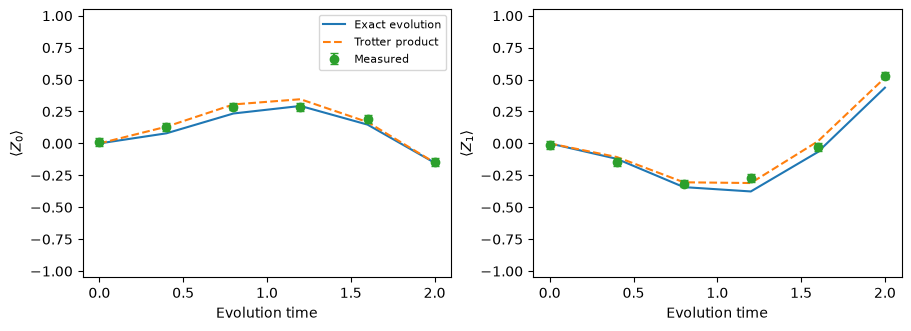

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), layout="constrained")
for index, axis in enumerate(axes):
    values = dynamics[dynamics["Observable"] == f"Z{index}"]
    axis.plot(values["Time"], values["Exact"], label="Exact evolution")
    axis.plot(values["Time"], values["Trotter"], "--", label="Trotter product")
    axis.errorbar(values["Time"], values["Sampled"], yerr=values["SE"], fmt="o", capsize=3, label="Measured")
    axis.set(xlabel="Evolution time", ylabel=rf"$\langle Z_{index}\rangle$", ylim=(-1.05, 1.05))
axes[0].legend(fontsize=8)
plt.show()

## 4. Swap the rotation implementation

- Pass a different `rz_method` to `trotter_first_order` to change the rotations inside each Pauli exponential.
- `ham_sim_trotter` and the measurement runner keep the same interfaces.
- Here we use `comparator_based_rz_cascade`, which implements approximate rotations with measurement feedback.
- `epsilon` controls individual rotations; it is not a bound on the full simulation error.

In [10]:
from guppyalgos.primitives.rotations import comparator_based_rz_cascade, n_comparator_based_rz_cascade_ancillas

epsilon = 0.01
rus_step = trotter_first_order(
    hamiltonian, n_qubits, rz_method=comparator_based_rz_cascade(epsilon),
)
rus_ancillas = n_comparator_based_rz_cascade_ancillas(epsilon)

### Build the RUS evolution circuit

- Use the same Hamiltonian, initial state, and time step as above; sample the comparator implementation at step 2.
- Only the rotation implementation changes. The builder returns the preparation circuit for a chosen number of steps.

In [11]:
def make_rus_preparation(steps):
    evolve_rus = ham_sim_trotter(rus_step, steps, time_step, n_qubits)

    @guppy
    def prepare_rus_at_time(qreg: array[qubit, 2]) -> None:
        transversal(h, qreg)
        evolve_rus(qreg)

    return prepare_rus_at_time

### Sample one comparison point

- Use **256 shots** at step **2** ($t=0.4$).
- Both $Z_0$ and $Z_1$ can be read from the same computational-basis shots. The library estimates each expectation and its standard error separately.
- The emulator executes the comparator's measurement-feedback loops as part of every shot.

In [12]:
rus_rows = []
for steps in [2]:
    samples = sample_direct(
        make_rus_preparation(steps), zqp.String.from_str("Z0", n_qubits),
        seed=900 + steps, shots=256, extra_qubits=rus_ancillas,
    )
    for index in range(n_qubits):
        label = f"Z{index}"
        operator = zqp.RealTermSum.from_str(label, n_qubits)
        stats = estimate_pauli_observable_expectation_from_bitstrings(operator, {label: samples})
        rus_rows.append({"Time": steps * time_step, "Observable": label,
                         "Sampled": stats.expectation, "SE": stats.standard_error})
rus_dynamics = pd.DataFrame(rus_rows)

### Overlay the results

- Circles show standard-Rz samples; squares show comparator-Rz samples, with one-standard-error bars.
- The comparator point lies on the same time grid and uses the same observables as the standard run. Compare its error bars with the standard-Rz samples and Trotter reference; exact evolution is also shown.
- Comparator results also include rotation-approximation error; error bars describe sampling uncertainty only.

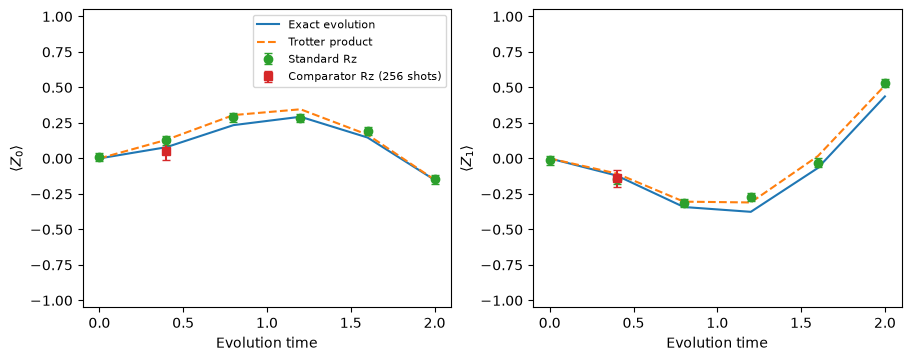

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), layout="constrained")
for index, axis in enumerate(axes):
    label = f"Z{index}"
    standard = dynamics[dynamics["Observable"] == label]
    comparator = rus_dynamics[rus_dynamics["Observable"] == label]
    axis.plot(standard["Time"], standard["Exact"], label="Exact evolution")
    axis.plot(standard["Time"], standard["Trotter"], "--", label="Trotter product")
    axis.errorbar(standard["Time"], standard["Sampled"], yerr=standard["SE"],
                  fmt="o", capsize=3, label="Standard Rz")
    axis.errorbar(comparator["Time"], comparator["Sampled"], yerr=comparator["SE"],
                  fmt="s", capsize=3, label="Comparator Rz (256 shots)")
    axis.set(xlabel="Evolution time", ylabel=rf"$\langle Z_{index}\rangle$", ylim=(-1.05, 1.05))
axes[0].legend(fontsize=8)
plt.show()

## Explore further

- Use the {doc}`QPE demo </examples/phase_estimation/phase_estimation_demo>` to estimate energy eigenvalues with controlled evolution.
- Explore {doc}`Pauli exponentials </examples/pauli_exponential/pauli_exponential>` to see how the rotation and CX-ladder implementations fit together.